In [2]:
# imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from methods import ACADEMIC_OPERATOR_LIST

# Detection

## detected release distribution

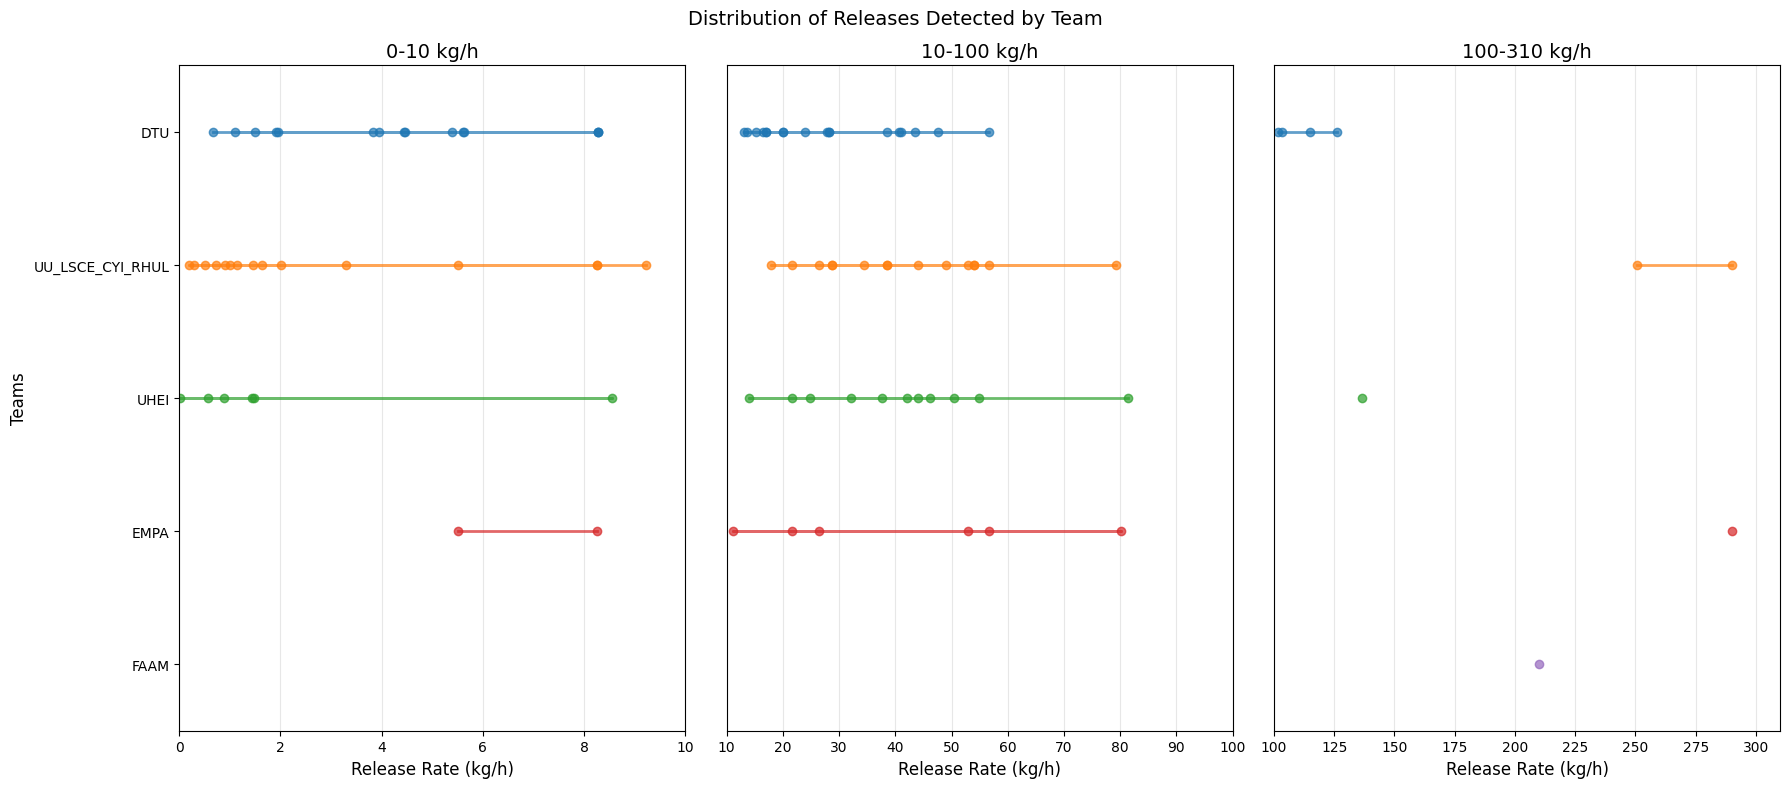

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from methods import load_release_summary, ACADEMIC_OPERATOR_LIST

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Colors for different categories
# colors = ['#2E8B57', '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA500', '#9370DB', '#20B2AA', '#FF69B4']

# Process data for each team - include ALL teams regardless of detections
team_data = []
for operator in ACADEMIC_OPERATOR_LIST:
    df = load_release_summary(operator)
    df_qc = df[df['stanford_kept']]  # Only QC passing releases
    
    # Get release rates for detected releases (empty array if no detections)
    detected_releases = df_qc[df_qc['operator_detected'] & df_qc['non_zero_release']]['release_rate_kgh'] if len(df_qc) > 0 else pd.Series(dtype=float)
    
    team_data.append({
        'team': operator,
        'release_rates': detected_releases.values if len(detected_releases) > 0 else np.array([]),
        'count': len(detected_releases)
    })

# Sort teams by number of detections
team_data.sort(key=lambda x: x['count'], reverse=True)

# Define x-axis ranges
ranges = [(0, 10), (10, 100), (100, 310)]
range_labels = ['0-10 kg/h', '10-100 kg/h', '100-310 kg/h']

# Create subplots for each range
for subplot_idx, (x_min, x_max) in enumerate(ranges):
    ax = axes[subplot_idx]
    
    # Plot each team's data as a horizontal line
    for i, data in enumerate(team_data):
        # Filter releases within this range
        releases_in_range = data['release_rates'][(data['release_rates'] >= x_min) & (data['release_rates'] < x_max)]
        
        y_position = len(team_data) - (i + 1)
        
        if len(releases_in_range) > 0:
            # Plot line connecting all points
            ax.plot(releases_in_range, [y_position] * len(releases_in_range), 
                    'o-', # color=colors[i % len(colors)], 
                    markersize=6, linewidth=2, alpha=0.7,
                    label=f"{data['team']} ({len(releases_in_range)} detections)")
        else:
            # Plot empty line for teams with no detections in this range
            ax.plot([], [], 'o-', # color=colors[i % len(colors)], 
                    markersize=6, linewidth=2, alpha=0.7,
                    label=f"{data['team']} (0 detections)")

    # Customize the subplot
    ax.set_ylabel('Teams' if subplot_idx == 0 else '', fontsize=12)
    ax.set_xlabel('Release Rate (kg/h)', fontsize=12)
    ax.set_title(f'{range_labels[subplot_idx]}', fontsize=14)
    
    # Set x-axis limits
    ax.set_xlim(x_min, x_max)
    
    # MANUALLY SET Y-AXIS LIMITS to show all teams
    ax.set_ylim(-0.5, len(team_data) - 0.5)
    
    # Set y-axis labels only for the first subplot
    if subplot_idx == 0:
        ax.set_yticks(range(len(team_data)))
        ax.set_yticklabels([data['team'] for data in reversed(team_data)])
    else:
        ax.set_yticks([])
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='x')

# Add overall title
fig.suptitle('Distribution of Releases Detected by Team', fontsize=14, y=0.98)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.savefig('report/plots/academic_teams/academic_teams_detected_releases_distributions.png')
plt.show()

## detection limit

UHEI detected all non-zero releases.


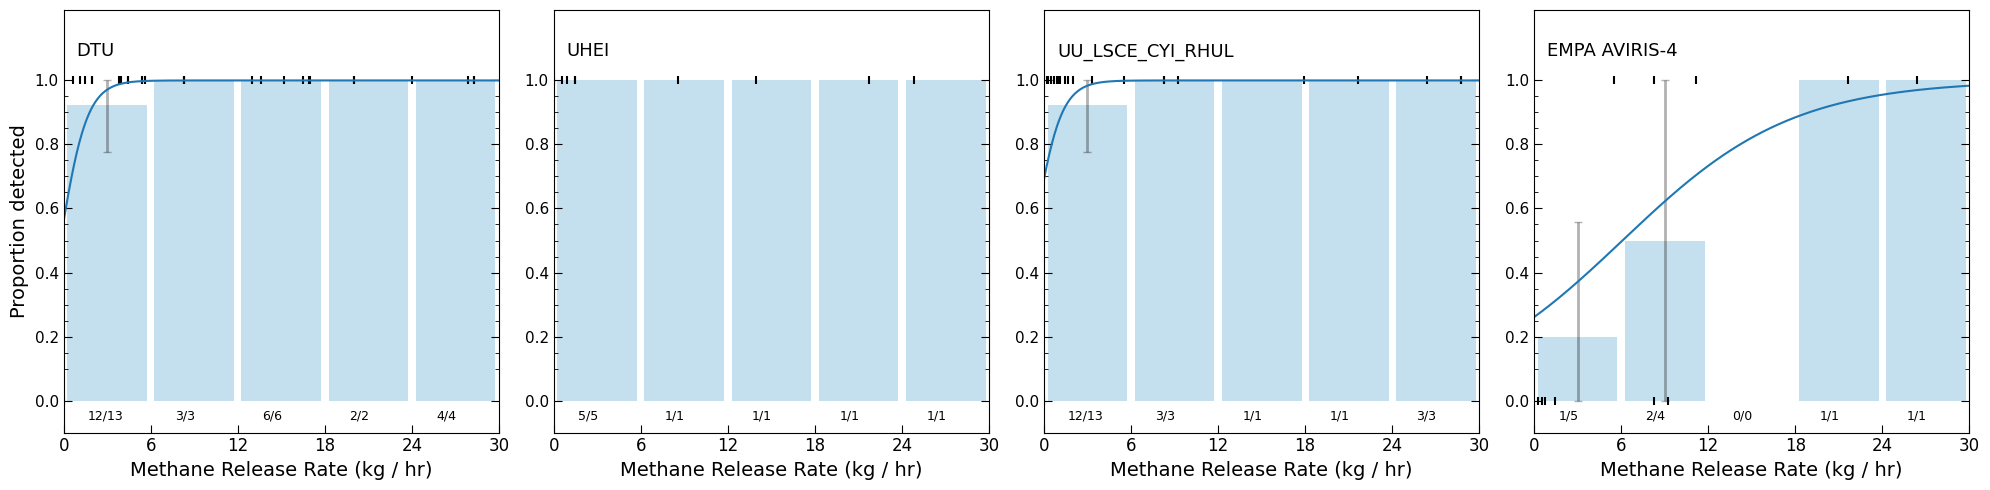

In [33]:
from plot_methods import plot_detection_limit, make_detection_limit_plot, plot_logistic_regression

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax = ax.flatten()
n_bins = 5
threshold = 30
ops = [op for op in ACADEMIC_OPERATOR_LIST if op not in ['FAAM']]

for i, operator in enumerate(ops):
    make_detection_limit_plot(ax=ax[i], operator=operator, n_bins=n_bins,threshold=threshold)
    ax[i].set_ylabel('Proportion detected') if i == 0 else ax[i].set_ylabel('')
    try:
        plot_logistic_regression(ax=ax[i], threshold=threshold, operator=operator)
    except ValueError as e:
        if 'at least 2 classes' in str(e):
            print(f'{operator} detected all non-zero releases.')


plt.tight_layout()
plt.savefig("report/plots/academic_teams/academic_ops_detection_limit_prob_under_30kgh.png")
plt.show()

## histogram

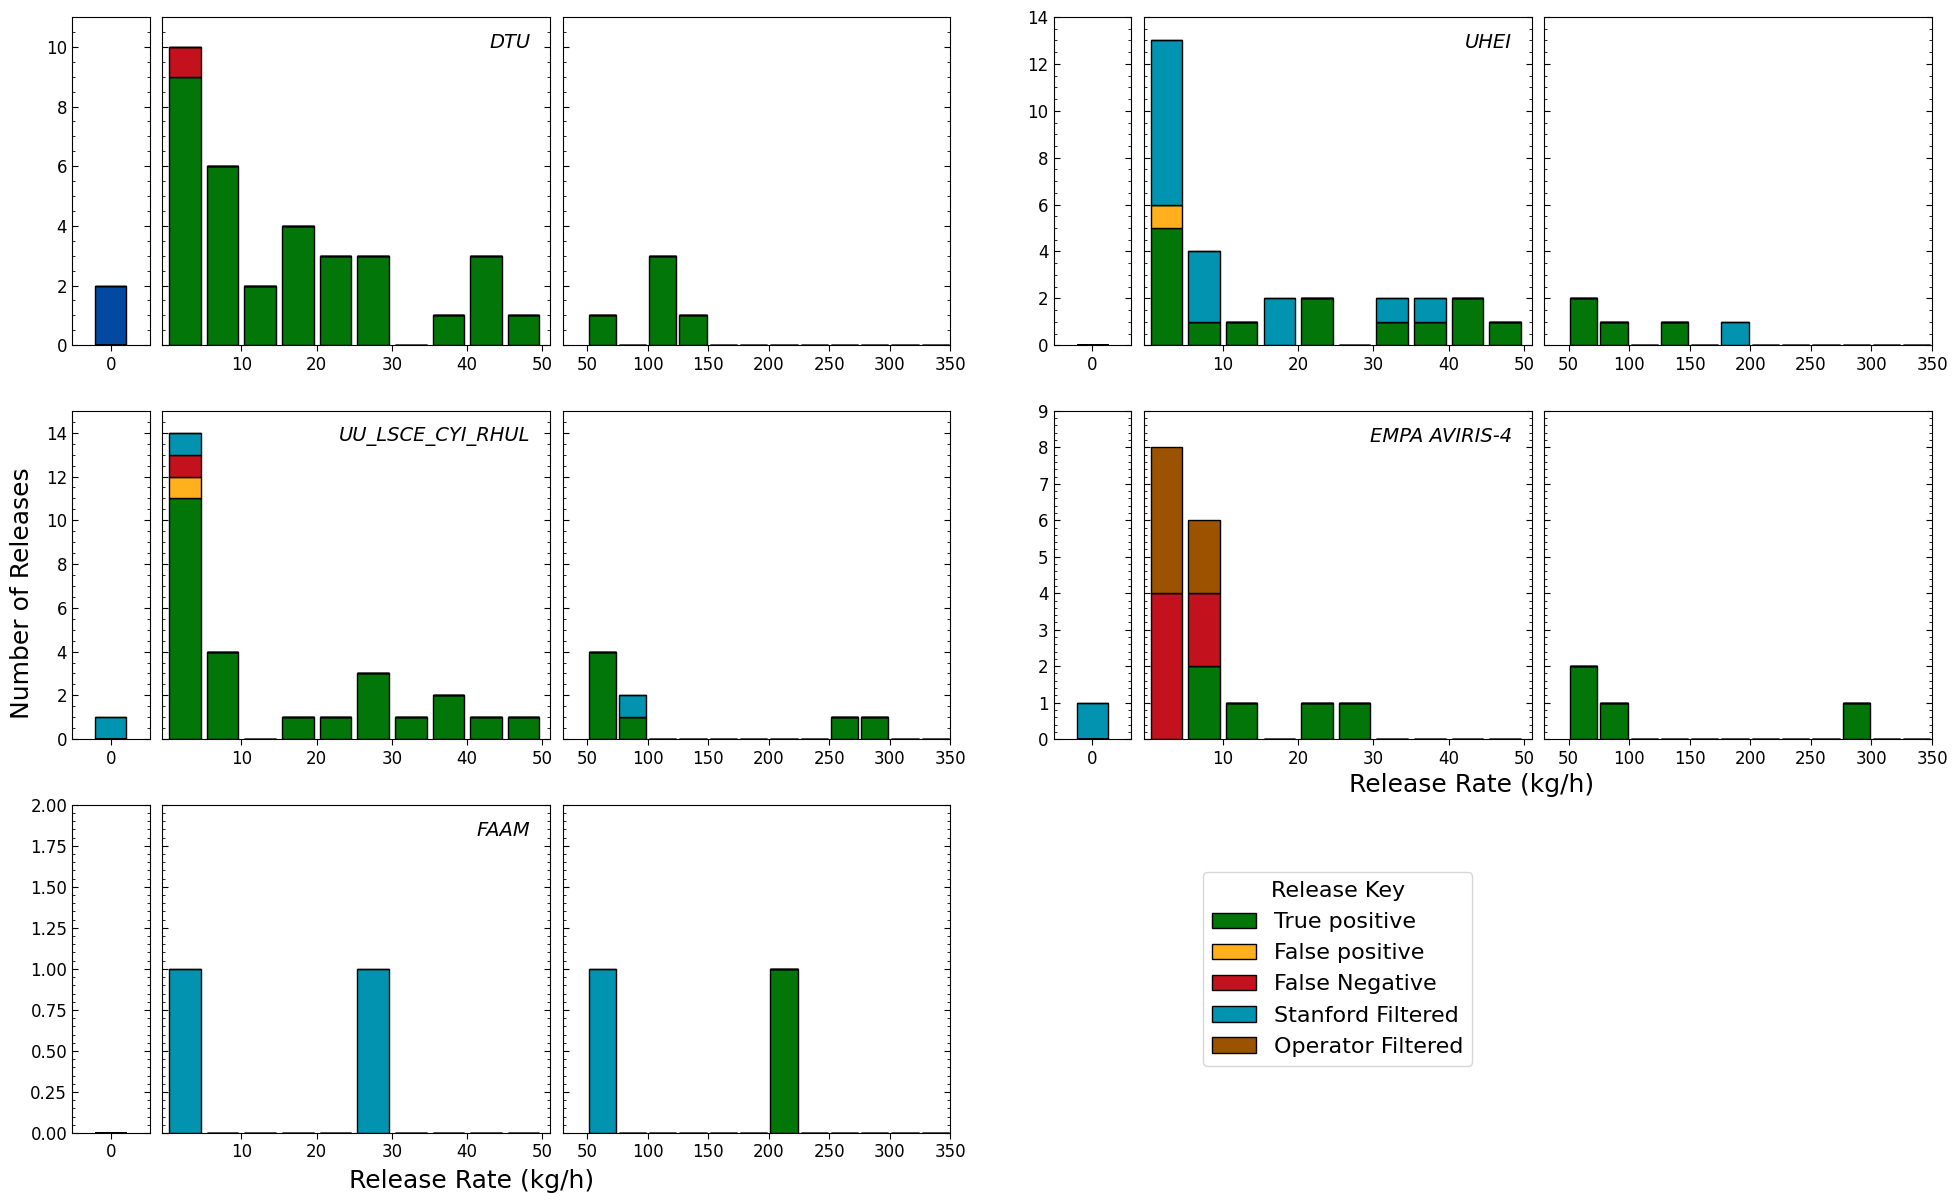

In [44]:
import matplotlib.pyplot as plt
import math
import numpy as np
from matplotlib.patches import Patch
from methods import OPERATOR_LIST
from plot_methods import make_releases_histogram, OPERATOR_PLOT_TITLES

def make_operator_histogram_plots(OPERATOR_LIST, fig, axes):

    k = 0
    for i, operator in enumerate(OPERATOR_LIST):
        if operator in OPERATOR_PLOT_TITLES.keys():
            title = OPERATOR_PLOT_TITLES[operator]
        else: 
            title = operator
        if i % 2 == 0:
            make_releases_histogram(operator, fig=fig, ax=[axes[k, 0], axes[k, 1], axes[k, 2]])
            axes[k, 3].axis('off')
            axes[k, 0].set_ylabel('')
            axes[k, 2].legend_.remove()
            
            # title text box
            axes[k, 1].text(0.95, 0.95, f"{title}",
                transform=axes[k, 1].transAxes, ha='right', va='top', fontsize=14, fontstyle='italic')
            
        else:
            make_releases_histogram(operator, fig=fig, ax=[axes[k, 4], axes[k, 5], axes[k, 6]])
            axes[k, 6].legend_.remove()
            axes[k, 4].set_ylabel('')
            # axes[k, 7].axis('off')

            # title text box
            axes[k, 5].text(0.95, 0.95, f"{title}",
                transform=axes[k, 5].transAxes, ha='right', va='top', fontsize=14, fontstyle='italic')
            k += 1
        
    plt.subplots_adjust(left=0.05,
                        bottom=0.05,
                        right=0.98,
                        top=0.98,
                        wspace=0.05,
                        hspace=0.2)

fig, axes = plt.subplots(3, 7, figsize=(20, 12), gridspec_kw={'width_ratios': [0.4, 2, 2, 0.4, 0.4, 2, 2]})
make_operator_histogram_plots(ACADEMIC_OPERATOR_LIST, fig, axes)

# Common label for x-axis on all subplots
txt_x_label1 = fig.text(0.25, 0.00, 'Release Rate (kg/h)', ha='center', va='bottom', fontsize=18)
txt_x_label2 = fig.text(0.75, 0.33, 'Release Rate (kg/h)', ha='center', va='bottom', fontsize=18)

# Common label for y-axis on all subplots
txt_y_label = fig.text(0.025, 0.5, 'Number of Releases', ha='center', va='center', fontsize=18, rotation=90)

for k in [4, 5, 6]:
    axes[2, k].axis('off')

# set legend 
handles, labels = axes[0, 2].get_legend_handles_labels()
axes[2, 5].axis('on')
axes[2, 5].set_xticks([])
axes[2, 5].set_yticks([])
for spine in axes[2, 5].spines.values():
    spine.set_visible(False)
axes[2, 5].legend(handles, labels, loc='center', fontsize=16, title='Release Key', title_fontsize=16)
#axes[0, 6].legend(fontsize=16, title='Release Key', title_fontsize=18)

plt.savefig("report/plots/academic_teams/academic_ops_histograms_2_cols.png")


# quantification

## parity plots

/Users/audreymcmanemin/anaconda3/lib/python3.10/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


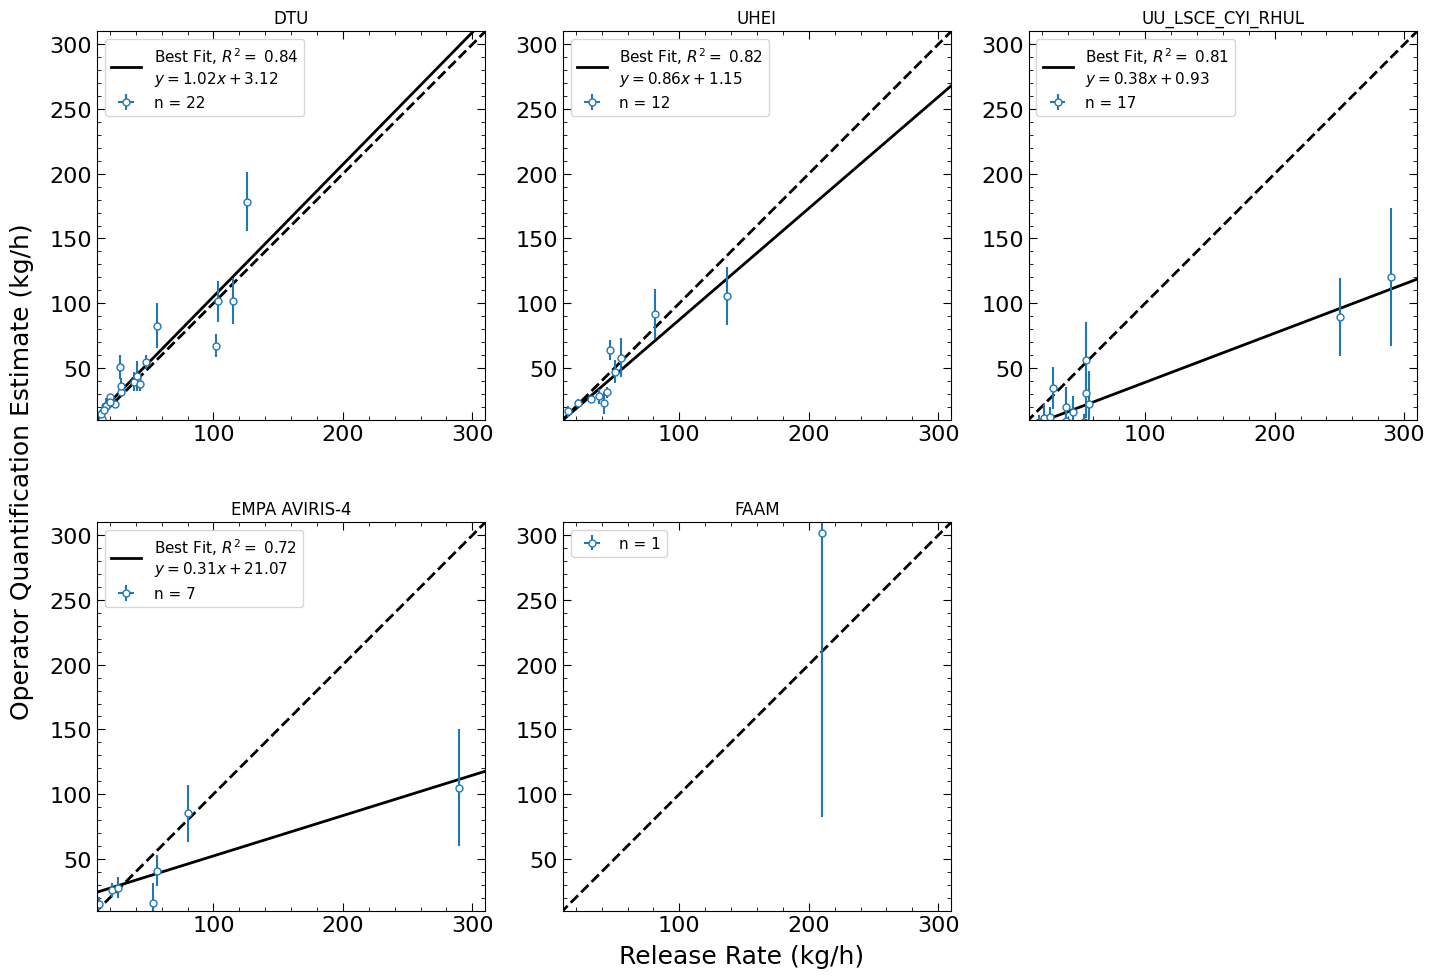

In [5]:
from plot_methods import make_parity_plot, get_parity_data, ACADEMIC_OPERATOR_LIST

fig, ax = plt.subplots(2, 3, figsize=[15, 10])
ax = ax.flatten()

for (k, op) in enumerate(ACADEMIC_OPERATOR_LIST):
    [data, desc] = get_parity_data(op)
    make_parity_plot(data, desc, ax=ax[k], plot_lim=[10, 310])
    ax[k].set_xlabel('')
    ax[k].set_ylabel('')

txt_y_label = fig.text(0.02, 0.5, 'Operator Quantification Estimate (kg/h)', ha='center', va='center', fontsize=18, rotation=90)
txt_x_label = fig.text(0.5, 0.015, 'Release Rate (kg/h)', ha='center', va='center', fontsize=18)


plt.subplots_adjust(left=0.07,
                        bottom=0.05,
                        right=0.95,
                        top=0.95)

ax[5].axis('off')

plt.savefig('report/plots/academic_teams/parity_academic_ops_above_10kgh.png')

## wind

/Users/audreymcmanemin/anaconda3/lib/python3.10/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


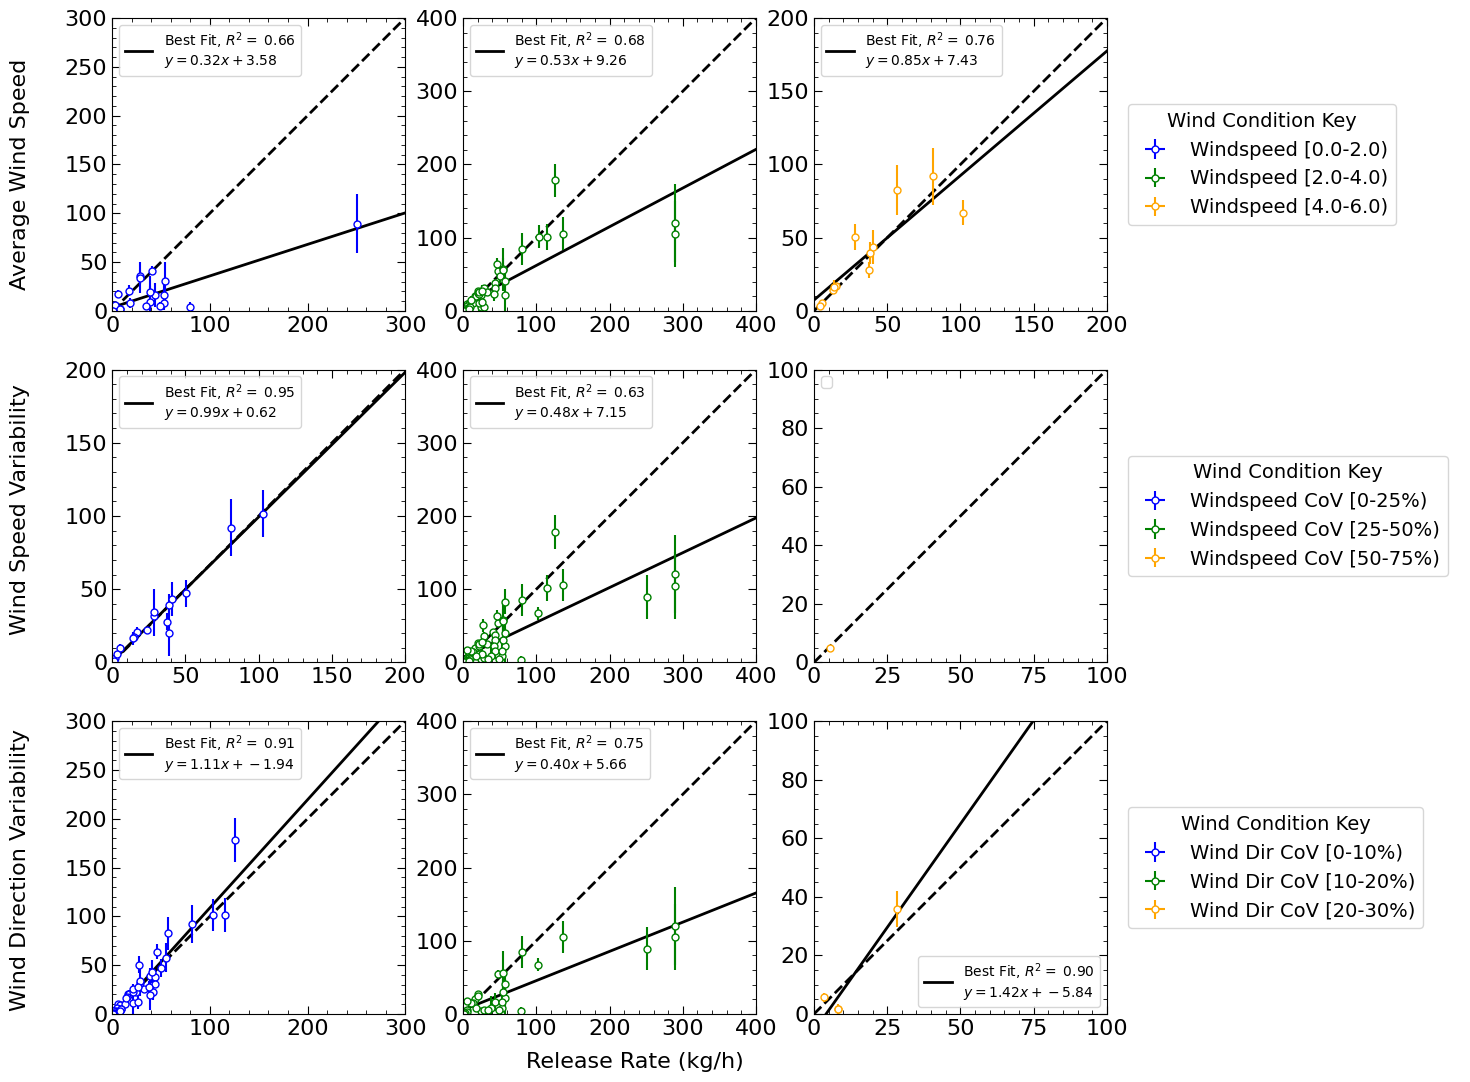

In [1]:
from plot_methods import make_parity_plot, get_parity_data, remove_wind_label, WINDSPEED_BIN_COLOR_MAP
import matplotlib.pyplot as plt

all_windspeed_bins = list(WINDSPEED_BIN_COLOR_MAP.keys())[:-1]
total_num_bins = len(all_windspeed_bins)

op = 'academic_no_faam'
fig, ax = plt.subplots(3, 4, figsize=[15, 12], sharex=False, sharey=False,
                       gridspec_kw={'wspace': 0.18, 'hspace': 0.2})

[data, desc] = get_parity_data(op, wind_analysis=True)

# --- ROW 1: WIND SPEED ---
k = 0    
windspeed_bins = data.windspeed_bin.unique().sort_values()

# legend in row 1 
make_parity_plot(data, desc, ax=ax[k, 0], wind_analysis='speed_avg')
handles, labels = ax[k, 0].get_legend_handles_labels()
ax[k, 0].cla()

for i, bin in enumerate(windspeed_bins[:3]):
    bin_data = data[data.windspeed_bin == bin]
    make_parity_plot(bin_data, desc, ax=ax[k, i], wind_analysis='speed_avg')
    ax[k, i].set_title('')
    ax[k, i].set_xlabel('') 
    ax[k, i].set_ylabel('')  
    ax[k, i] = remove_wind_label(ax[k, i])

ax[k, 3].set_xticks([])
ax[k, 3].set_yticks([])
for spine in ax[k, 3].spines.values():
    spine.set_visible(False)
ax[k, 3].legend(handles[1:4], labels[1:4], loc='center left', fontsize=14, title="Wind Condition Key", title_fontsize=14, bbox_to_anchor=(-0.15, 0.5))


# --- ROW 2: WIND SPEED VARIABILITY ---
k = 1
wind_bins = data.windspeed_variation_coeff_bin.unique().sort_values()

# legend in row 2
make_parity_plot(data, desc, ax=ax[k, 0], wind_analysis='speed_var_coeff')
handles, labels = ax[k, 0].get_legend_handles_labels()
ax[k, 0].cla()

for i, bin in enumerate(wind_bins[:3]):
    bin_data = data[data.windspeed_variation_coeff_bin == bin]
    make_parity_plot(bin_data, desc, ax=ax[k, i], wind_analysis='speed_var_coeff')
    ax[k, i].set_title('')   
    ax[k, i].set_xlabel('') 
    ax[k, i].set_ylabel('')  
    ax[k, i] = remove_wind_label(ax[k, i])

# legend in column 1
ax[k, 3].set_xticks([])
ax[k, 3].set_yticks([])
for spine in ax[k, 3].spines.values():
    spine.set_visible(False)
ax[k, 3].legend(handles[1:4], labels[1:4], loc='center left', fontsize=14, title="Wind Condition Key", title_fontsize=14, bbox_to_anchor=(-0.15, 0.5))


# --- ROW 3: WIND DIRECTION VARIABILITY ---
k = 2
dir_bins = data.winddir_variation_coeff_bin.unique().sort_values()
# legend in row 2
make_parity_plot(data, desc, ax=ax[k, 0], wind_analysis='dir_var_coeff')
handles, labels = ax[k, 0].get_legend_handles_labels()
ax[k, 0].cla()

for i, bin in enumerate(dir_bins[:3]):
    bin_data = data[data.winddir_variation_coeff_bin == bin]
    make_parity_plot(bin_data, desc, ax=ax[k, i], wind_analysis='dir_var_coeff')
    ax[k, i].set_title('')
    ax[k, i].set_xlabel('') 
    ax[k, i].set_ylabel('')    
    ax[k, i] = remove_wind_label(ax[k, i])

# legend in column 1
ax[k, 3].set_xticks([])
ax[k, 3].set_yticks([])
for spine in ax[k, 3].spines.values():
    spine.set_visible(False)
ax[k, 3].legend(handles[1:4], labels[1:4], loc='center left', fontsize=14, title="Wind Condition Key", title_fontsize=14, bbox_to_anchor=(-0.15, 0.5))


# Layout & Labels
fig.subplots_adjust(left=0.08, right=0.98, top=0.93, bottom=0.1)

# Row labels
fig.text(0.02, 0.8, 'Average Wind Speed', va='center', ha='center', fontsize=16, rotation=90)
fig.text(0.02, 0.52, 'Wind Speed Variability', va='center', ha='center', fontsize=16, rotation=90)
fig.text(0.02, 0.22, 'Wind Direction Variability', va='center', ha='center', fontsize=16, rotation=90)

# X axis label
fig.text(0.43, 0.06, 'Release Rate (kg/h)', va='center', ha='center', fontsize=16)

# Save the figure
plt.savefig('report/plots/academic_teams/parity_wind_analysis_academic_ops_windspeed_bins.png')


/Users/audreymcmanemin/anaconda3/lib/python3.10/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


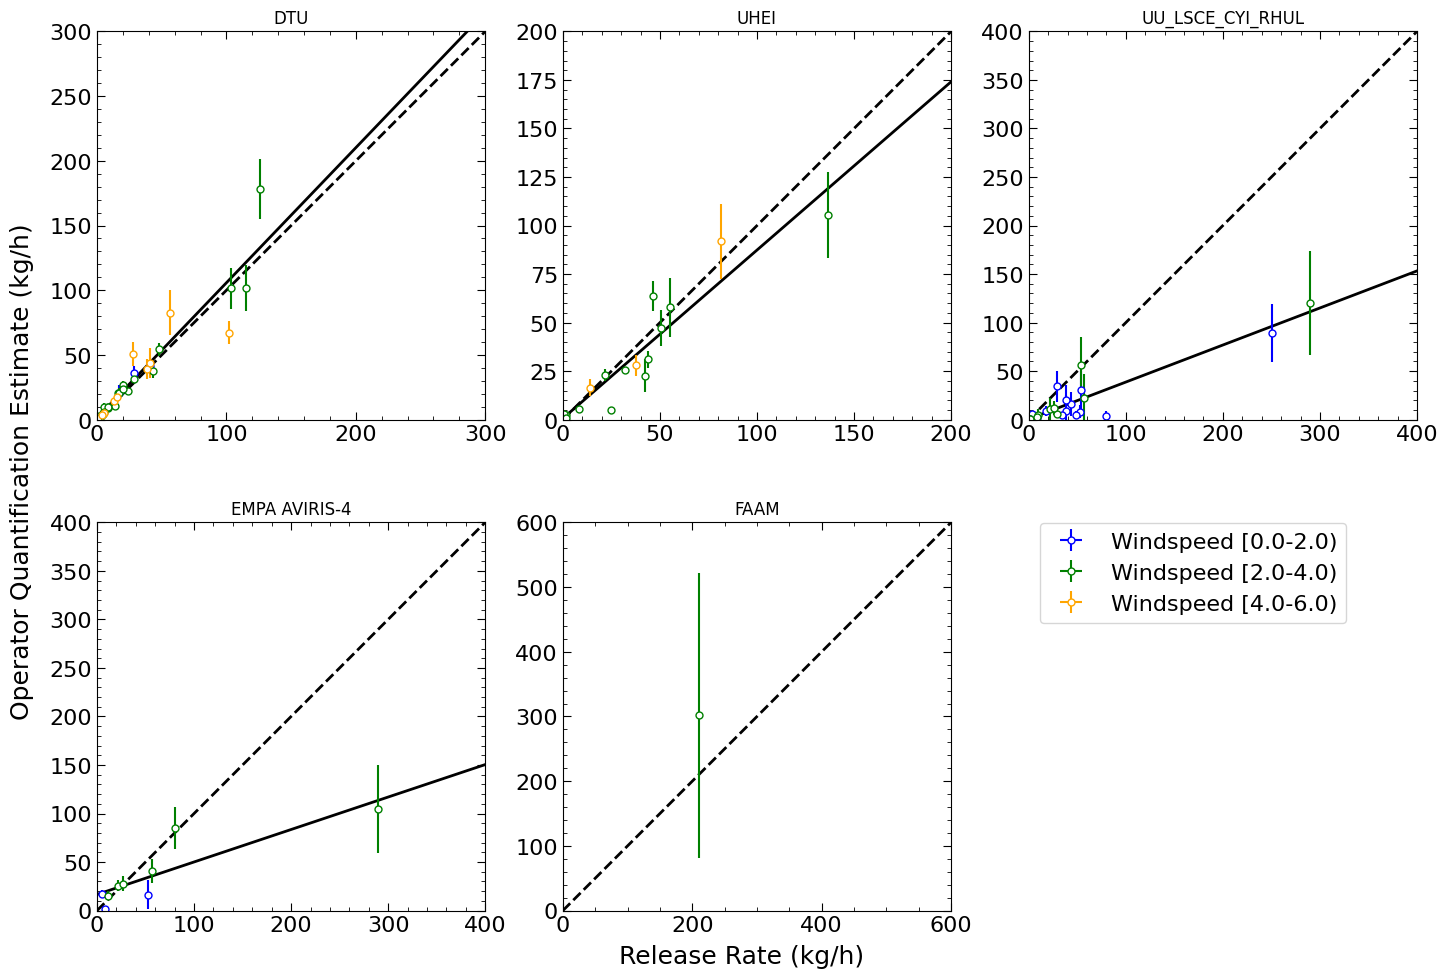

In [8]:
# wind speed for all operators 
from plot_methods import make_parity_plot, get_parity_data, remove_wind_label, WINDSPEED_BIN_COLOR_MAP
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=[15, 10])
ax = ax.flatten()

for (k, op) in enumerate(ACADEMIC_OPERATOR_LIST):
    [data, desc] = get_parity_data(op, wind_analysis=True)
    make_parity_plot(data, desc, ax=ax[k], wind_analysis='speed_avg')
    ax[k].legend().set_visible(False)
    ax[k].set_xlabel('')
    ax[k].set_ylabel('')

txt_y_label = fig.text(0.02, 0.5, 'Operator Quantification Estimate (kg/h)', ha='center', va='center', fontsize=18, rotation=90)
txt_x_label = fig.text(0.5, 0.015, 'Release Rate (kg/h)', ha='center', va='center', fontsize=18)

plt.subplots_adjust(left=0.07,
                        bottom=0.05,
                        right=0.95,
                        top=0.95)

handles, labels = ax[0].get_legend_handles_labels()
ax[5].set_xticks([])
ax[5].set_yticks([])
for spine in ax[5].spines.values():
    spine.set_visible(False)
ax[5].legend(handles[1:], labels[1:], loc='upper left', fontsize=16)

#plt.suptitle('Technology Type Parity Plots by Average Windspeed (20m) of Releases', fontsize=20)
# plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('report/plots/academic_teams/parity_windspeed_avg_academic_ops.png')
